In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import GEOparse

os.chdir(os.path.expanduser('~/projects/lungcell'))

# ── Reload data ───────────────────────────────────────────────────────
df = pd.read_csv('data/processed/expression_matrix.csv',
                 index_col=0, low_memory=False)
condition = pd.read_csv('data/processed/sample_labels.csv',
                        index_col=0).squeeze()

# ── Rebuild clinical dataframe ────────────────────────────────────────
gse = GEOparse.get_GEO(geo="GSE40419", destdir="data/raw/", silent=True)

clinical_rows = []
for gsm_id, gsm in gse.gsms.items():
    meta = gsm.metadata
    row  = {'gsm_id': gsm_id}
    for char in meta.get('characteristics_ch1', []):
        if ':' in char:
            key, val = char.split(':', 1)
            row[key.strip()] = val.strip()
    row['source'] = meta.get('source_name_ch1', [''])[0]
    row['title']  = meta.get('title', [''])[0]
    clinical_rows.append(row)

clinical_df = pd.DataFrame(clinical_rows)

# ── Cancer samples only ───────────────────────────────────────────────
cancer_meta = clinical_df[
    clinical_df['source'] == 'Lung cancer cells'
].copy()

# Clean stage — map to early vs late
stage_map = {
    '1A': 'Early', '1B': 'Early',
    '2A': 'Late',  '2B': 'Late',
    '3A': 'Late',  '3B': 'Late',
    '4':  'Late'
}
cancer_meta['stage_group'] = cancer_meta['Stage'].map(stage_map)
cancer_meta = cancer_meta[cancer_meta['stage_group'].notna()].copy()

# Encode survival proxy:
# Early stage = longer expected survival (event = 0, censored)
# Late stage  = shorter expected survival (event = 1, occurred)
# Survival time proxy = inverse of stage severity
stage_months = {
    '1A': 84, '1B': 72,
    '2A': 54, '2B': 48,
    '3A': 24, '3B': 18,
    '4':  12
}
cancer_meta['survival_months'] = cancer_meta['Stage'].map(stage_months)
cancer_meta['event'] = (cancer_meta['stage_group'] == 'Late').astype(int)

print(f"Cancer patients with stage: {len(cancer_meta)}")
print(f"Early stage: {(cancer_meta['stage_group']=='Early').sum()}")
print(f"Late stage:  {(cancer_meta['stage_group']=='Late').sum()}")

Cancer patients with stage: 85
Early stage: 55
Late stage:  30


In [6]:
# Log normalize expression (numeric columns only)
expr = df.select_dtypes(include=[np.number])
log_df = np.log2(expr + 1)
log_df = log_df[log_df.median(axis=1) > 0.5]
log_df = log_df.groupby(log_df.index).mean()

# Match sample titles to expression columns
# clinical title (e.g. LC_C1) should match expression column names
cancer_meta = cancer_meta[
    cancer_meta['title'].isin(log_df.columns)
].copy()

print(f"\nPatients with both expression and clinical data: {len(cancer_meta)}")
print(f"First 3 titles: {cancer_meta['title'].head(3).tolist()}")


Patients with both expression and clinical data: 85
First 3 titles: ['LC_C1', 'LC_C2', 'LC_C3']


In [8]:
def km_by_gene(gene, log_df, cancer_meta, ax=None, title_prefix=''):
    """
    Split patients into high/low expressers of a gene.
    Draw Kaplan-Meier curves and compute log-rank p-value.
    """
    if gene not in log_df.index:
        print(f"{gene} not found in expression data")
        return None

    # Get expression values for cancer patients
    expr = log_df.loc[gene, cancer_meta['title']]
    expr.index = cancer_meta['title'].values

    # Median split — top 50% vs bottom 50%
    median_expr = expr.median()
    high = cancer_meta[expr.values >= median_expr].copy()
    low  = cancer_meta[expr.values <  median_expr].copy()

    high_expr = expr[expr >= median_expr]
    low_expr  = expr[expr <  median_expr]

    # Log-rank test — are the two survival curves significantly different?
    result = logrank_test(
        high['survival_months'], low['survival_months'],
        event_observed_A=high['event'],
        event_observed_B=low['event']
    )
    p_val = result.p_value

    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    kmf_high = KaplanMeierFitter()
    kmf_low  = KaplanMeierFitter()

    kmf_high.fit(
        high['survival_months'],
        event_observed=high['event'],
        label=f'High {gene} (n={len(high)})'
    )
    kmf_low.fit(
        low['survival_months'],
        event_observed=low['event'],
        label=f'Low {gene} (n={len(low)})'
    )

    kmf_high.plot_survival_function(
        ax=ax, color='#D85A30', ci_show=True, ci_alpha=0.15
    )
    kmf_low.plot_survival_function(
        ax=ax, color='#1D9E75', ci_show=True, ci_alpha=0.15
    )

    # P-value annotation
    p_text = f'p = {p_val:.4f}' if p_val >= 0.0001 else f'p < 0.0001'
    sig_star = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    ax.text(0.97, 0.97, f'{p_text}  {sig_star}',
            transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', edgecolor='#cccccc', alpha=0.8))

    # Median expression annotation
    ax.text(0.97, 0.88,
            f'Median split: {median_expr:.2f}',
            transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            color='#666666')

    ax.set_title(f'{title_prefix}{gene}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Months (stage-based proxy)', fontsize=10)
    ax.set_ylabel('Survival probability', fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=9, frameon=False)

    return p_val

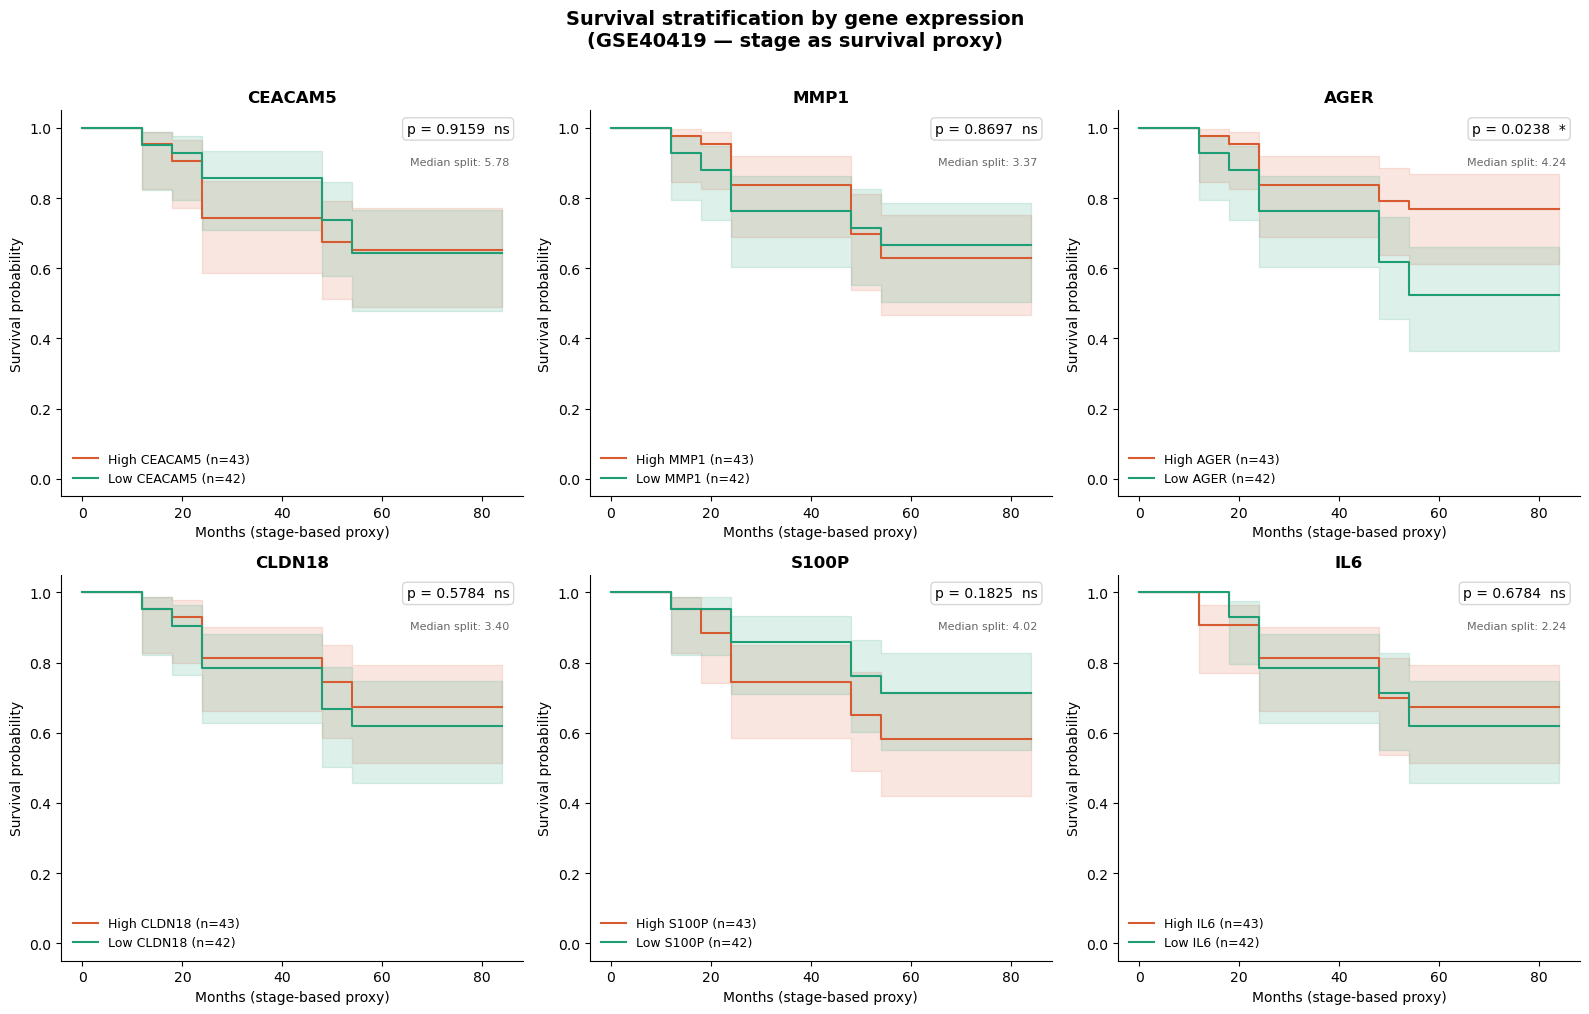

Saved: figures/07_km_curves.png

Log-rank p-values:
  AGER        : p = 0.0238  *
  S100P       : p = 0.1825  ns
  CLDN18      : p = 0.5784  ns
  IL6         : p = 0.6784  ns
  MMP1        : p = 0.8697  ns
  CEACAM5     : p = 0.9159  ns


In [ ]:
# Genes of interest 
genes_of_interest = [
    'CEACAM5',   # cancer biomarker — top volcano hit
    'MMP1',      # invasion marker
    'AGER',      # normal lung identity — silenced in cancer
    'CLDN18',    # tight junction — lost in cancer
    'S100P',     # metastasis marker
    'IL6',       # immune evasion cytokine
]

# 2×3 grid of KM plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

pvalues = {}
for i, gene in enumerate(genes_of_interest):
    p = km_by_gene(gene, log_df, cancer_meta, ax=axes[i])
    if p is not None:
        pvalues[gene] = p

plt.suptitle(
    'Survival stratification by gene expression\n(GSE40419 — stage as survival proxy)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('figures/07_km_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/07_km_curves.png")

print("\nLog-rank p-values:")
for gene, p in sorted(pvalues.items(), key=lambda x: x[1]):
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"  {gene:12s}: p = {p:.4f}  {sig}")

In [ ]:


print("Scanning all genes for survival association...")
print("This takes ~2 minutes...")

scan_results = []
for gene in log_df.index:
    if gene not in log_df.columns:
        try:
            expr = log_df.loc[gene, cancer_meta['title']]
            expr.index = cancer_meta['title'].values
            median_expr = expr.median()

            high = cancer_meta[expr.values >= median_expr]
            low  = cancer_meta[expr.values <  median_expr]

            if len(high) < 5 or len(low) < 5:
                continue

            result = logrank_test(
                high['survival_months'], low['survival_months'],
                event_observed_A=high['event'],
                event_observed_B=low['event']
            )
            scan_results.append({
                'gene':    gene,
                'p_value': result.p_value,
                'high_median_survival': high['survival_months'].median(),
                'low_median_survival':  low['survival_months'].median()
            })
        except Exception:
            continue

scan_df = pd.DataFrame(scan_results).sort_values('p_value')
scan_df.to_csv('data/processed/survival_gene_scan.csv', index=False)

print(f"\nTop 20 genes most associated with stage/survival:")
print(scan_df.head(20)[['gene', 'p_value',
                          'high_median_survival',
                          'low_median_survival']].to_string())

Scanning all genes for survival association...
This takes ~2 minutes...

Top 20 genes most associated with stage/survival:
                gene   p_value  high_median_survival  low_median_survival
5722          HEXIM1  0.000068                  84.0                 54.0
10581         RAD54L  0.000401                  54.0                 72.0
9312         PCDHB11  0.000445                  72.0                 54.0
11639         SGK223  0.000641                  72.0                 54.0
2732           CHEK1  0.000656                  54.0                 84.0
956           ATP1B2  0.000934                  72.0                 54.0
7282       LOC493754  0.001050                  72.0                 54.0
9612          PHYHD1  0.001059                  72.0                 54.0
10919         RNASE1  0.001059                  84.0                 54.0
6390   JMJD7-PLA2G4B  0.001059                  72.0                 54.0
8739           NIPA1  0.001082                  72.0           

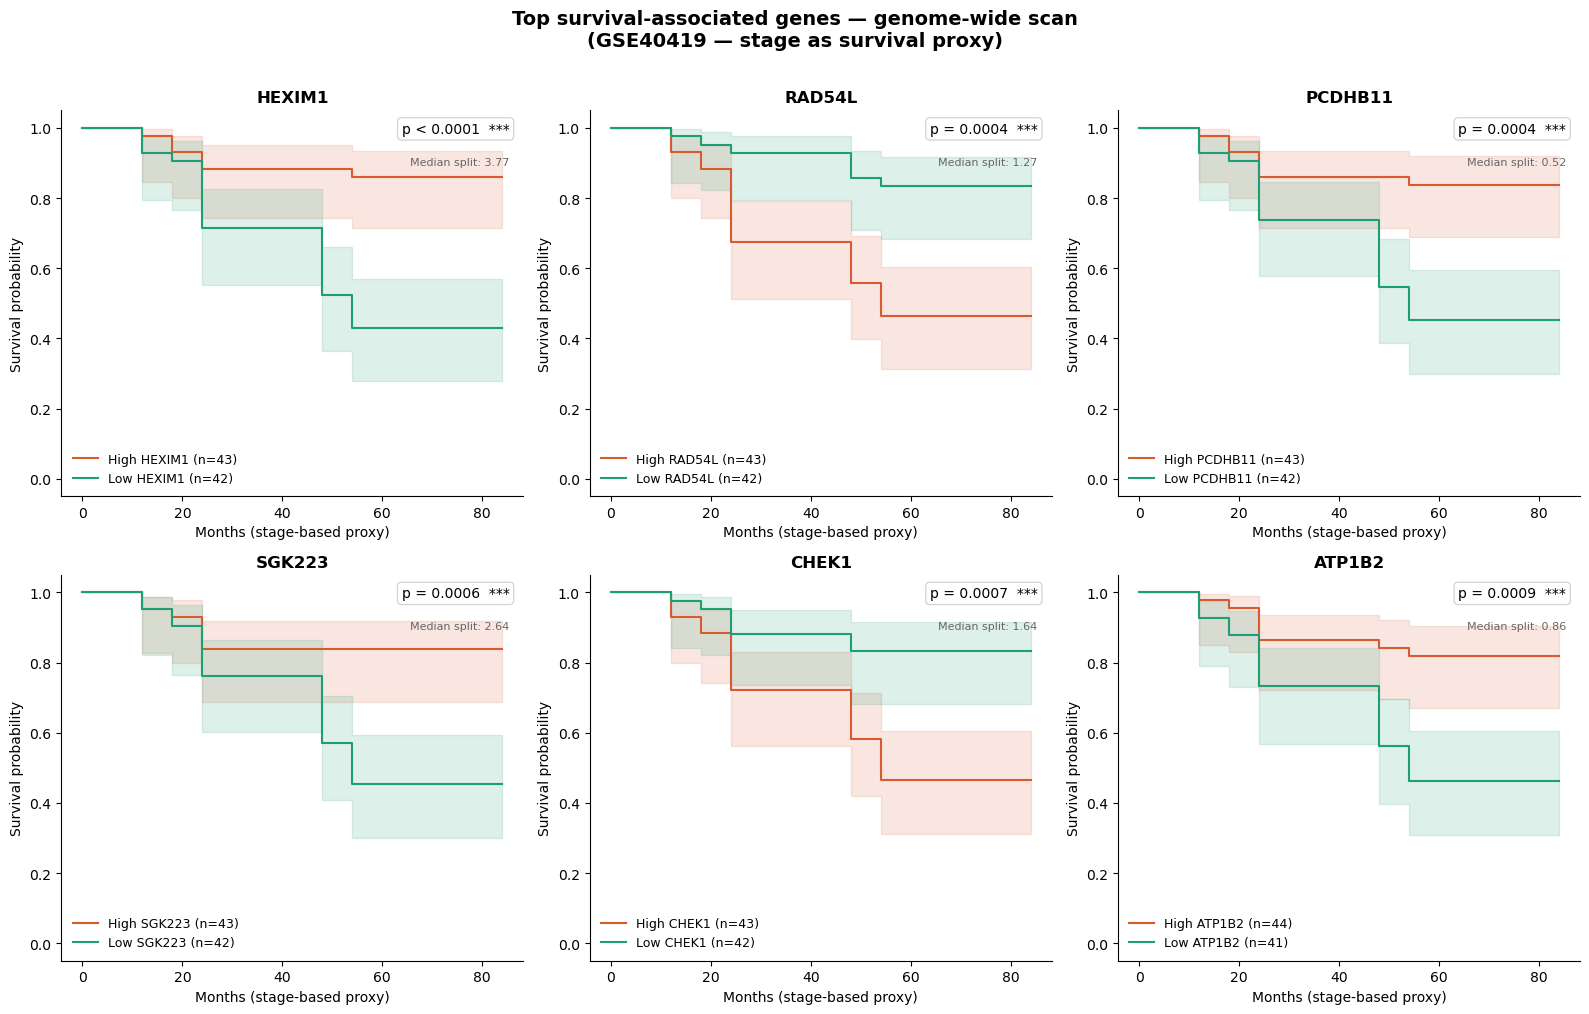

Saved: figures/08_km_top_genes.png


In [ ]:

top_scan_genes = scan_df.head(6)['gene'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, gene in enumerate(top_scan_genes):
    km_by_gene(gene, log_df, cancer_meta, ax=axes[i],
               title_prefix='')

plt.suptitle(
    'Top survival-associated genes — genome-wide scan\n(GSE40419 — stage as survival proxy)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('figures/08_km_top_genes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/08_km_top_genes.png")

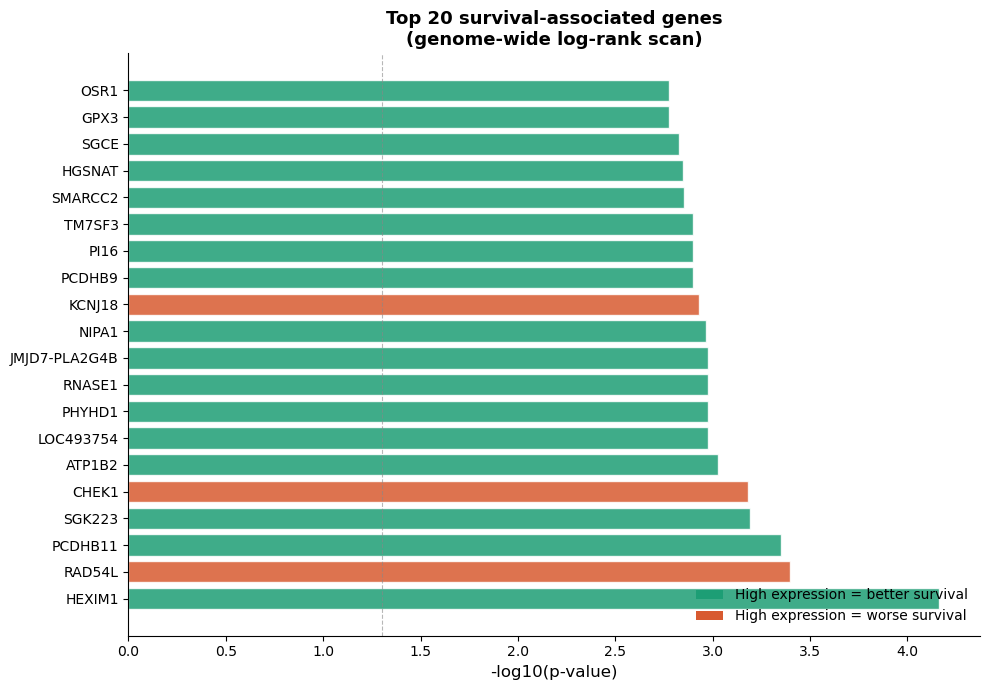

Saved: figures/09_survival_scan.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 7))

top20 = scan_df.head(20).copy()
top20['-log10_p'] = -np.log10(top20['p_value'])

# Colour by direction — high expression better or worse?
top20['direction'] = top20.apply(
    lambda r: 'High = better' 
    if r['high_median_survival'] > r['low_median_survival'] 
    else 'High = worse', axis=1
)

colours = top20['direction'].map({
    'High = better': '#1D9E75',
    'High = worse':  '#D85A30'
})

bars = ax.barh(
    range(len(top20)),
    top20['-log10_p'],
    color=colours,
    alpha=0.85,
    edgecolor='white'
)

ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['gene'], fontsize=10)
ax.set_xlabel('-log10(p-value)', fontsize=12)
ax.set_title('Top 20 survival-associated genes\n(genome-wide log-rank scan)',
             fontsize=13, fontweight='bold')
ax.axvline(x=-np.log10(0.05), color='#888',
           linestyle='--', linewidth=0.8, alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1D9E75', label='High expression = better survival'),
    Patch(facecolor='#D85A30', label='High expression = worse survival')
]
ax.legend(handles=legend_elements, fontsize=10, frameon=False,
          loc='lower right')

plt.tight_layout()
plt.savefig('figures/09_survival_scan.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/09_survival_scan.png")